In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely import wkb

In [3]:
import seaborn as sns

# Research Area
- City of London
- Westminster
- Hackney
- Camden

# Time Range
- First period: 2016-06-30, 2016-12-31, **2017-06-30**, 2017-12-31, 2018-06-30, 2019-06-30
- Second period: 2022-06-30, 2022-12-31, **2023-06-30**, 2023-12-31, 2024-06-30, 2025-06-30

# First Period Analysis
## Import the data

In [4]:
citylondon_17 = pd.read_csv('data_source/period-2010-to-2017-E09000001-city of london.csv')
camden_17 = pd.read_csv('data_source/period-2010-to-2017-E09000007-camden.csv')
hackney_17 = pd.read_csv('data_source/period-2010-to-2017-E09000012-hackney.csv')
westminster_17 = pd.read_csv('data_source/period-2010-to-2017-E09000033-westminster.csv')

/tmp/ipykernel_104/722522668.py:1: DtypeWarning: Columns (5,10,11,19,21) have mixed types. Specify dtype option on import or set low_memory=False.
  citylondon_17 = pd.read_csv('data_source/period-2010-to-2017-E09000001-city of london.csv')
/tmp/ipykernel_104/722522668.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  hackney_17 = pd.read_csv('data_source/period-2010-to-2017-E09000012-hackney.csv')
/tmp/ipykernel_104/722522668.py:4: DtypeWarning: Columns (5,10,11,19,21) have mixed types. Specify dtype option on import or set low_memory=False.
  westminster_17 = pd.read_csv('data_source/period-2010-to-2017-E09000033-westminster.csv')


In [6]:
citylondon_17.columns

Index(['filter_period', 'billing_authority_name', 'geocode', 'uarn',
       'billing_reference', 'account_name', 'account_start_date',
       'searchable_address', 'postcode_id', 'geometry', 'occupation_state',
       'occupation_date', 'category_id', 'primary_description',
       'category_subgroup', 'category_group', 'rates_payable',
       'rateable_value', 'total_floor_area', 'unit_of_measure', 'from_date',
       'record_date', 'series', 'epoch'],
      dtype='object')

In [5]:
# Cleaning
citylondon_17N = citylondon_17[citylondon_17['rateable_value'] > 0]  # Remove outliers
citylondon_17N = citylondon_17N.dropna(subset=['rateable_value'])

camden_17N = camden_17[camden_17['rateable_value'] > 0]
camden_17N = camden_17N.dropna(subset=['rateable_value'])

hackney_17N = hackney_17[hackney_17['rateable_value'] > 0]
hackney_17N = hackney_17N.dropna(subset=['rateable_value'])

westminster_17N = westminster_17[westminster_17['rateable_value'] > 0]
westminster_17N = westminster_17N.dropna(subset=['rateable_value'])

# Convert WKB geometry to Shapely objects
citylondon_17N['geom'] = citylondon_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_17N['geom'] = camden_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
hackney_17N['geom'] = hackney_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
westminster_17N['geom'] = westminster_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))

In [7]:
def extract_all_timepoints_unified(df, revaluation_year='2017'):
    """Extract timepoints for either 2017 or 2023 revaluation"""
    
    if revaluation_year == '2017':
        timepoints = {
            'pre_12m': df[(df['series'] == 2010) & (df['epoch'] == 21)],
            'pre_6m': df[(df['series'] == 2010) & (df['epoch'] == 23)],
            'revaluation': df[(df['series'] == 2017) & (df['epoch'] == 2)],
            'post_6m': df[(df['series'] == 2017) & (df['epoch'] == 4)],
            'post_12m': df[(df['series'] == 2017) & (df['epoch'] == 7)],
            'post_24m': df[(df['series'] == 2017) & (df['epoch'] == 13)]
        }
    elif revaluation_year == '2023':
        timepoints = {
            'pre_12m': df[(df['series'] == 2017) & (df['epoch'] == 32)],
            'pre_6m': df[(df['series'] == 2017) & (df['epoch'] == 34)],
            'revaluation': df[(df['series'] == 2023) & (df['epoch'] == 2)],
            'post_6m': df[(df['series'] == 2023) & (df['epoch'] == 5)],
            'post_12m': df[(df['series'] == 2023) & (df['epoch'] == 8)],
            'post_24m': df[(df['series'] == 2023) & (df['epoch'] == 15)]
        }
    else:
        raise ValueError("revaluation_year must be '2017' or '2023'")
    
    return timepoints

## Dynamic Bunching Analysis
- Tax bracket creep是否真实存在？
  
### Function
- 检测门槛聚集效应：量化企业在税率门槛附近的分布扭曲程度
- 追踪时间演变：观察bunching效应在重估前后的动态变化
- 识别bracket creep：证明税率门槛确实影响企业行为

### 分析机制
- 对比分布密度：比较门槛前**1000英镑**区间 vs 门槛后1000英镑区间的企业数量 \
ratio = (number of businesses in £1000 range before threshold) / (number of businesses in £1000 range after threshold)
- 计算扭曲比例：**ratio < 1**表示门槛前企业"异常稀少"，存在bunching \
distortion_pct = (ratio - 1) * 100
- 量化扭曲程度：distortion_pct显示偏离正常分布的百分比



### <font color ='#DE3163'>可以尝试不同窗口大小：
- window=500   更精细的分析
- window=2000  更宽泛的范围  
- window=1500  中等范围

In [8]:
def dynamic_bunching_analysis(timepoints_dict, thresholds=[15000], window=1000):
    results = []
    
    for period, df in timepoints_dict.items():
        if len(df) == 0:
            continue
            
        df_clean = df.dropna(subset=['rateable_value'])
        
        for threshold in thresholds:
            before = len(df_clean[(df_clean['rateable_value'] >= threshold-window) & 
                                 (df_clean['rateable_value'] < threshold)])
            after = len(df_clean[(df_clean['rateable_value'] >= threshold) & 
                                (df_clean['rateable_value'] <= threshold+window)])
            
            ratio = before / max(after, 1)
            distortion = (ratio - 1) * 100
            
            results.append({
                'period': period,
                'threshold': threshold,
                'before_count': before,
                'after_count': after,
                'ratio': ratio,
                'distortion_pct': distortion
            })
    
    return pd.DataFrame(results)

Test

In [50]:
# Test dynamic_bunching_analysis function directly
def test_bunching_function():
    # Test with one borough's 2017 data
    test_timepoints = extract_all_timepoints_unified(westminster_23N, '2023')
    
    print("Timepoints available:")
    for period, df in test_timepoints.items():
        print(f"  {period}: {len(df)} records")
    
    # Run bunching analysis
    bunching_result = dynamic_bunching_analysis(test_timepoints)
    
    print(f"\nBunching result shape: {bunching_result.shape}")
    print(f"Bunching columns: {list(bunching_result.columns)}")
    print("\nSample bunching data:")
    print(bunching_result.head())
    
    return bunching_result

# Test the function
test_result = test_bunching_function()

Timepoints available:
  pre_12m: 0 records
  pre_6m: 0 records
  revaluation: 0 records
  post_6m: 0 records
  post_12m: 0 records
  post_24m: 0 records

Bunching result shape: (0, 0)
Bunching columns: []

Sample bunching data:
Empty DataFrame
Columns: []
Index: []


## Survival analysis
- "哪些企业因为bracket creep而被迫退出市场？"➡️识别可能受bracket creep影响的企业群体
- 如果门槛附近企业退出率更高，证明bracket creep造成了额外压力

### 核心功能
- 追踪企业去向：监测同一批企业在不同时间点是否仍然存在 ➡️ 退出是立即发生还是延迟发生？
- 计算退出率`survival_rate`：量化有多少企业在重估后"消失"了
- 对比分析：比较门槛附近企业 `survival_rate_near_threshold` vs 整体企业的生存表现 `survival_rate_total`

### 分析机制
- 基准建立：以重估前12个月的企业为起始群体
- 生存追踪：检查这些企业的UARN在后续时间点是否还存在
- 分组对比：
整体生存率：所有企业的存活比例 \
门槛附近生存率：15000门槛±window(2000)范围内企业的存活比例

### 关键指标

### <font color ='#DE3163'>可以尝试不同窗口大小

In [9]:
def track_business_survival(timepoints_dict):
    """Track business survival across different time points"""
    
    # Baseline: Use 12 months before revaluation
    baseline = timepoints_dict['pre_12m'].dropna(subset=['rateable_value'])
    baseline_uarns = set(baseline['uarn'])
    
    survival_data = []
    
    for period, df in timepoints_dict.items():
        if len(df) == 0:
            continue
            
        df_clean = df.dropna(subset=['rateable_value'])
        current_uarns = set(df_clean['uarn'])
        
        # Calculate survival rate
        survived = len(baseline_uarns & current_uarns)
        survival_rate = survived / len(baseline_uarns) * 100
        
        # Analyze by threshold groups
        for threshold in [15000]:

            near_threshold = baseline[
                (baseline['rateable_value'] >= threshold-2000) & 
                (baseline['rateable_value'] <= threshold+2000)
            ]
            near_threshold_uarns = set(near_threshold['uarn'])
            
            survived_near = len(near_threshold_uarns & current_uarns)
            survival_rate_near = survived_near / len(near_threshold_uarns) * 100 if len(near_threshold_uarns) > 0 else 0
            
            survival_data.append({
                'period': period,
                'threshold': threshold,
                'total_baseline': len(baseline_uarns),
                'near_threshold_baseline': len(near_threshold_uarns),
                'survived_total': survived,
                'survived_near_threshold': survived_near,
                'survival_rate_total': survival_rate,
                'survival_rate_near_threshold': survival_rate_near
            })
    
    return pd.DataFrame(survival_data)

## Analyze business response strategies by periods
- 企业应对bracket creep是一次性行为还是持续调整过程？
  
### 核心功能
- 时间维度分析：对比企业在重估后6个月 vs 12个月 vs 24 months的不同应对策略
- 策略演变追踪：观察企业应对策略是否随时间变化
- 短期vs长期反应：区分即时反应和深思熟虑后的调整

### 分析价值
1. 策略时间模式
- 即时反应 (6个月)：企业的第一反应，通常是被动接受或立即上诉
- 成熟策略 (12个月)：有时间规划的策略，如空间重组、长期上诉等
短期反应 (6个月)：企业的即时应对策略
中期调整 (12个月)：经过观察和规划的策略修正
- 长期适应 (24个月)：成熟稳定的策略选择

2. 适应过程识别
- 策略转换：从acceptance转为appeal，或从appeal转为space_reduction策略转换 ：从接受转为上诉，或从上诉转为 space_reduction
- 策略稳定性：哪些策略在6-12个月间保持一致
- 学习效应：企业是否在观察其他企业后调整策略

3. Bracket Creep影响的时间差异
- 受影响企业：是否在不同时期采用不同策略来应对15k门槛
- 应对有效性：哪些策略在短期有效，哪些需要长期实施
- 压力持续性：bracket creep的压力是否随时间缓解
  
### <font color ='#DE3163'>标准？策略分类机制
- value减少：Successful Appeal：post值 < reval值的90%（成功降低评估价值）
- area减少：Space Reduction：面积减少超过20%（分割租赁策略）
- Acceptance：post值与reval值差异小于baseline的10%（接受重估）
- Unknown：其他情况

In [10]:
def analyze_business_responses(timepoints_dict):
    """Analyze business response strategies"""
    
    baseline = timepoints_dict['pre_12m'].dropna(subset=['rateable_value'])
    revaluation = timepoints_dict['revaluation'].dropna(subset=['rateable_value'])
    post_6m = timepoints_dict['post_6m'].dropna(subset=['rateable_value'])
    post_12m = timepoints_dict['post_12m'].dropna(subset=['rateable_value'])
    #post_24m = timepoints_dict['post_24m'].dropna(subset=['rateable_value'])
    
    # Merge the data
    baseline_indexed = baseline.set_index('uarn')[['rateable_value', 'total_floor_area']]
    revaluation_indexed = revaluation.set_index('uarn')[['rateable_value', 'total_floor_area']]
    post_6m_indexed = post_6m.set_index('uarn')[['rateable_value', 'total_floor_area']]
    post_12m_indexed = post_12m.set_index('uarn')[['rateable_value', 'total_floor_area']]
    #post_24m_indexed = post_12m.set_index('uarn')[['rateable_value', 'total_floor_area']]
    
    # Find businesses that exist across all time points
    common_uarns = set(baseline_indexed.index) & set(revaluation_indexed.index) & set(post_12m_indexed.index)
    
    all_responses = []
    
    # Analyze responses at 6 months
    common_6m = set(baseline_indexed.index) & set(revaluation_indexed.index) & set(post_6m_indexed.index)
    
    for uarn in common_6m:
        base_val = baseline_indexed.loc[uarn, 'rateable_value']
        reval_val = revaluation_indexed.loc[uarn, 'rateable_value'] 
        post_val = post_6m_indexed.loc[uarn, 'rateable_value']
        
        base_area = baseline_indexed.loc[uarn, 'total_floor_area']
        post_area = post_6m_indexed.loc[uarn, 'total_floor_area']
        
        # Classify response strategies
        strategy = 'unknown'
        
        if post_val < reval_val * 0.9:  # Value decrease
            strategy = 'successful_appeal'
        elif post_area < base_area * 0.8:  # Area reduction
            strategy = 'space_reduction'
        elif abs(post_val - reval_val) < base_val * 0.1:  # Acceptance
            strategy = 'acceptance'
        
        # Check if affected by bracket creep
        affected_15k = (base_val < 15000 and reval_val >= 15000)
        
        all_responses.append({
            'uarn': uarn,
            'period': 'post_6m',
            'baseline_value': base_val,
            'revaluation_value': reval_val,
            'post_value': post_val,
            'baseline_area': base_area,
            'post_area': post_area,
            'strategy': strategy,
            'affected_15k_threshold': affected_15k
        })
    
    # Analyze responses at 12 months
    common_12m = set(baseline_indexed.index) & set(revaluation_indexed.index) & set(post_12m_indexed.index)
    
    for uarn in common_12m:
        base_val = baseline_indexed.loc[uarn, 'rateable_value']
        reval_val = revaluation_indexed.loc[uarn, 'rateable_value'] 
        post_val = post_12m_indexed.loc[uarn, 'rateable_value']
        
        base_area = baseline_indexed.loc[uarn, 'total_floor_area']
        post_area = post_12m_indexed.loc[uarn, 'total_floor_area']
        
        # Classify response strategies
        strategy = 'unknown'
        
        if post_val < reval_val * 0.9:  # Value decrease
            strategy = 'successful_appeal'
        elif post_area < base_area * 0.8:  # Area reduction
            strategy = 'space_reduction'
        elif abs(post_val - reval_val) < base_val * 0.1:  # Acceptance
            strategy = 'acceptance'
        
        # Check if affected by bracket creep
        affected_15k = (base_val < 15000 and reval_val >= 15000)
        
        all_responses.append({
            'uarn': uarn,
            'period': 'post_12m',
            'baseline_value': base_val,
            'revaluation_value': reval_val,
            'post_value': post_val,
            'baseline_area': base_area,
            'post_area': post_area,
            'strategy': strategy,
            'affected_15k_threshold': affected_15k
        })
    
    return pd.DataFrame(all_responses)

In [11]:
def comprehensive_analysis_unified(df, revaluation_year='2017'):
    """Run complete analysis for either 2017 or 2023 revaluation"""
    
    # Extract timepoints based on revaluation year
    timepoints = extract_all_timepoints_unified(df, revaluation_year)
    
    # Run all analyses
    bunching_results = dynamic_bunching_analysis(timepoints)
    survival_results = track_business_survival(timepoints)
    response_results = analyze_business_responses(timepoints)
    #risk_results = classify_exit_risk(timepoints)
    
    return {
        'revaluation_year': revaluation_year,
        'bunching': bunching_results,
        'survival': survival_results,
        'responses': response_results,
        #'risk_classification': risk_results,
        'timepoints_data': timepoints
    }


In [13]:
def create_comparison_tables(all_results):
    """ Create cross-borough comparison tables"""
    
    # Bunching effect comparison
    bunching_comparison = pd.concat([
        results['bunching'].assign(Borough=borough) 
        for borough, results in all_results.items()
    ])
    
    # Survival rate comparison
    survival_comparison = pd.concat([
        results['survival'].assign(Borough=borough) 
        for borough, results in all_results.items()
    ])
    
    # Response strategy comparison
    response_comparison = pd.concat([
        results['responses'].assign(Borough=borough) 
        for borough, results in all_results.items()
    ])
    
    return bunching_comparison, survival_comparison, response_comparison


## Results

In [14]:
# Execute analysis for each borough
camden_results_17 = comprehensive_analysis(camden_17N)
citylondon_results_17 = comprehensive_analysis(citylondon_17N)
hackney_results_17 = comprehensive_analysis(hackney_17N)
westminster_results_17 = comprehensive_analysis(westminster_17N)

# Merge results
all_borough_results_17 = {
    'Camden': camden_results_17,
    'City_of_London': citylondon_results_17, 
    'Hackney': hackney_results_17,
    'Westminster': westminster_results_17
}


# Generate comparative analysis
bunching_all, survival_all, response_all = create_comparison_tables(all_borough_results_17)

summary_stats = bunching_all.groupby(['Borough', 'period'])['distortion_pct'].mean().unstack()
survival_summary = survival_all[survival_all['period'] == 'post_24m'].groupby('Borough')['survival_rate_near_threshold'].mean()

print("Bunching Distortion by Borough:")
print(summary_stats.round(1))

print("\n24-Month Survival Rates:")
print(survival_summary.round(1))

NameError: name 'comprehensive_analysis' is not defined

In [15]:
# Generate key insights for all four boroughs
def generate_cross_borough_insights(all_borough_results):
   print("="*80)
   print("CROSS-BOROUGH BRACKET CREEP ANALYSIS")
   print("="*80)
   
   for borough_name, results in all_borough_results.items():
       if results is None:
           continue
           
       print(f"\n{'='*20} {borough_name.upper()} {'='*20}")
       
       print(f"\n1. Bunching Effect Evolution:")
       bunching_summary = results['bunching'].pivot(index='period', columns='threshold', values='distortion_pct')
       print(results['bunching'])
       #print(bunching_summary.round(1))
       
       print(f"\n2. Business Survival Status:")
       survival_key = results['survival'][results['survival']['period'].isin(['revaluation', 'post_6m', 'post_12m', 'post_24m'])]
       survival_summary = survival_key.pivot(index='period', columns='threshold', values='survival_rate_near_threshold')
       print(survival_summary.round(1))
       
       print(f"\n3. Response Strategy Distribution:")
       strategy_counts = results['responses'].groupby('strategy').size()
       strategy_pct = (strategy_counts / strategy_counts.sum() * 100).round(1)
       for strategy, pct in strategy_pct.items():
           print(f"   {strategy}: {strategy_counts[strategy]} businesses ({pct}%)")
       
       print(f"\n4. Bracket Creep Impact:")
       affected_15k = results['responses']['affected_15k_threshold'].sum()
       total_businesses = len(results['responses'])
       affected_pct = (affected_15k / total_businesses * 100) if total_businesses > 0 else 0
       print(f"   Businesses pushed over £15k threshold: {affected_15k} ({affected_pct:.1f}%)")
       print(f"   Total analyzed businesses: {total_businesses}")

   # Cross-borough comparison summary
   print(f"\n{'='*25} COMPARATIVE SUMMARY {'='*25}")
   
   # Bunching distortion comparison (latest period)
   print("\nFinal Bunching Distortion (post_24m):")
   for borough_name, results in all_borough_results.items():
       if results is not None:
           latest_bunching = results['bunching'][results['bunching']['period'] == 'post_24m']
           if len(latest_bunching) > 0:
               distortion = latest_bunching['distortion_pct'].iloc[0]
               print(f"   {borough_name}: {distortion:.1f}%")
   
   # Survival rate comparison
   print("\nFinal Survival Rates (post_24m):")
   for borough_name, results in all_borough_results.items():
       if results is not None:
           latest_survival = results['survival'][results['survival']['period'] == 'post_24m']
           if len(latest_survival) > 0:
               survival_rate = latest_survival['survival_rate_near_threshold'].iloc[0]
               print(f"   {borough_name}: {survival_rate:.1f}%")
   
   # Bracket creep impact comparison
   print("\nBracket Creep Impact Comparison:")
   for borough_name, results in all_borough_results.items():
       if results is not None:
           affected = results['responses']['affected_15k_threshold'].sum()
           total = len(results['responses'])
           impact_rate = (affected / total * 100) if total > 0 else 0
           print(f"   {borough_name}: {affected}/{total} businesses ({impact_rate:.1f}%)")

In [19]:
# Execute cross-borough analysis
generate_cross_borough_insights(all_borough_results_17)

NameError: name 'all_borough_results_17' is not defined

## Second Period Analysis

In [17]:
# import the data
citylondon_23 = pd.read_csv('data_source/period-2017-to-2023-E09000001-city of london.csv')
camden_23 = pd.read_csv('data_source/period-2017-to-2023-E09000007-camden.csv')
hackney_23 = pd.read_csv('data_source/period-2017-to-2023-E09000012-hackney.csv')
westminster_23 = pd.read_csv('data_source/period-2017-to-2023-E09000033-westminster.csv')

# Cleaning
citylondon_23N = citylondon_23[citylondon_23['rateable_value'] > 0]  # Remove outliers
citylondon_23N = citylondon_23N.dropna(subset=['rateable_value'])

camden_23N = camden_23[camden_23['rateable_value'] > 0]
camden_23N = camden_23N.dropna(subset=['rateable_value'])

hackney_23N = hackney_23[hackney_23['rateable_value'] > 0]
hackney_23N = hackney_23N.dropna(subset=['rateable_value'])

westminster_23N = westminster_23[westminster_23['rateable_value'] > 0]
westminster_23N = westminster_23N.dropna(subset=['rateable_value'])

# Convert WKB geometry to Shapely objects
citylondon_23N['geom'] = citylondon_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_23N['geom'] = camden_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
hackney_23N['geom'] = hackney_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
westminster_23N['geom'] = westminster_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))

/tmp/ipykernel_104/2703687211.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  citylondon_23 = pd.read_csv('data_source/period-2017-to-2023-E09000001-city of london.csv')
/tmp/ipykernel_104/2703687211.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  camden_23 = pd.read_csv('data_source/period-2017-to-2023-E09000007-camden.csv')
/tmp/ipykernel_104/2703687211.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  hackney_23 = pd.read_csv('data_source/period-2017-to-2023-E09000012-hackney.csv')
/tmp/ipykernel_104/2703687211.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  westminster_23 = pd.read_csv('data_source/period-2017-to-2023-E09000033-westminster.csv')


In [ ]:
time_points_23 = {
    '2022-06-30': 'pre_12m',
    '2022-12-31': 'pre_6m', 
    '2023-06-30': 'revaluation',
    '2023-12-31': 'post_6m',
    '2024-06-30': 'post_12m',
    '2025-06-30': 'post_24m'
}
# Extract data from all time points
def extract_all_timepoints_23(df):
    timepoints = {
        'pre_12m': df[(df['series'] == 2017) & (df['epoch'] == 32)],
        'pre_6m': df[(df['series'] == 2017) & (df['epoch'] == 34)],
        'revaluation': df[(df['series'] == 2023) & (df['epoch'] == 2)],
        'post_6m': df[(df['series'] == 2023) & (df['epoch'] == 5)],
        'post_12m': df[(df['series'] == 2023) & (df['epoch'] == 8)],
        'post_24m': df[(df['series'] == 2023) & (df['epoch'] == 15)]
    }
    return timepoints

In [18]:
def analyze_both_revaluations_separate_data(data_2017, data_2023):
    """Analyze 2017 and 2023 revaluations using separate datasets"""
    
    # Analyze 2017 revaluation using 2017 dataset
    results_2017 = comprehensive_analysis_unified(data_2017, '2017')
    
    # Analyze 2023 revaluation using 2023 dataset  
    results_2023 = comprehensive_analysis_unified(data_2023, '2023')
    
    return {
        '2017_revaluation': results_2017,
        '2023_revaluation': results_2023
    }

# Execute analysis for all boroughs with both periods
camden_both_periods = analyze_both_revaluations_separate_data(camden_17N, camden_23N)
citylondon_both_periods = analyze_both_revaluations_separate_data(citylondon_17N, citylondon_23N)
hackney_both_periods = analyze_both_revaluations_separate_data(hackney_17N, hackney_23N)
westminster_both_periods = analyze_both_revaluations_separate_data(westminster_17N, westminster_23N)

# Combine all results
all_borough_both_periods = {
    'Camden': camden_both_periods,
    'City_of_London': citylondon_both_periods,
    'Hackney': hackney_both_periods,
    'Westminster': westminster_both_periods
}

In [20]:
# Generate comprehensive insights for both revaluation periods
def generate_dual_period_insights(all_borough_both_periods):
   print("="*80)
   print("DUAL REVALUATION ANALYSIS: 2017 vs 2023 BRACKET CREEP IMPACT")
   print("="*80)
   
   for borough_name, periods_data in all_borough_both_periods.items():
       print(f"\n{'='*25} {borough_name.upper()} {'='*25}")
       
       for period, results in periods_data.items():
           period_year = period.split('_')[0]
           print(f"\n--- {period_year} Revaluation Results ---")
           
           # 1. Bunching Effect
           print(f"\n1. Bunching Effect Evolution ({period_year}):")
           bunching_summary = results['bunching'].pivot(index='period', columns='threshold', values='distortion_pct')
           print(bunching_summary.round(1))
           
           # 2. Survival Rates
           print(f"\n2. Business Survival Status ({period_year}):")
           survival_key = results['survival'][results['survival']['period'].isin(['revaluation', 'post_6m', 'post_12m', 'post_24m'])]
           if len(survival_key) > 0:
               survival_summary = survival_key.pivot(index='period', columns='threshold', values='survival_rate_near_threshold')
               print(survival_summary.round(1))
           
           # 3. Response Strategies
           print(f"\n3. Response Strategy Distribution ({period_year}):")
           strategy_counts = results['responses'].groupby('strategy').size()
           strategy_pct = (strategy_counts / strategy_counts.sum() * 100).round(1)
           for strategy, pct in strategy_pct.items():
               print(f"   {strategy}: {strategy_counts[strategy]} businesses ({pct}%)")
           
           # 4. Bracket Creep Impact
           print(f"\n4. Bracket Creep Impact ({period_year}):")
           affected_15k = results['responses']['affected_15k_threshold'].sum()
           total_businesses = len(results['responses'])
           affected_pct = (affected_15k / total_businesses * 100) if total_businesses > 0 else 0
           print(f"   Businesses pushed over £15k threshold: {affected_15k} ({affected_pct:.1f}%)")
           print(f"   Total analyzed businesses: {total_businesses}")
       
       # Compare 2017 vs 2023 for this borough
       print(f"\n--- {borough_name} COMPARISON: 2017 vs 2023 ---")
       
       try:
           # Final bunching distortion comparison
           bunching_2017 = periods_data['2017_revaluation']['bunching']
           bunching_2023 = periods_data['2023_revaluation']['bunching']
           
           final_2017 = bunching_2017[bunching_2017['period'] == 'post_24m']['distortion_pct'].iloc[0]
           final_2023 = bunching_2023[bunching_2023['period'] == 'post_24m']['distortion_pct'].iloc[0]
           
           print(f"Final Bunching Distortion: 2017={final_2017:.1f}% vs 2023={final_2023:.1f}%")
           
           # Bracket creep impact comparison
           impact_2017 = periods_data['2017_revaluation']['responses']['affected_15k_threshold'].sum()
           total_2017 = len(periods_data['2017_revaluation']['responses'])
           impact_2023 = periods_data['2023_revaluation']['responses']['affected_15k_threshold'].sum()
           total_2023 = len(periods_data['2023_revaluation']['responses'])
           
           rate_2017 = (impact_2017/total_2017*100) if total_2017 > 0 else 0
           rate_2023 = (impact_2023/total_2023*100) if total_2023 > 0 else 0
           
           print(f"Bracket Creep Impact: 2017={rate_2017:.1f}% vs 2023={rate_2023:.1f}%")
           
       except Exception as e:
           print(f"Comparison data incomplete: {e}")

   # Cross-borough and cross-period summary
   print(f"\n{'='*30} OVERALL SUMMARY {'='*30}")
   
   print("\nFinal Bunching Distortion Comparison:")
   print("Borough          | 2017  | 2023  | Change")
   print("-" * 45)
   
   for borough_name, periods_data in all_borough_both_periods.items():
       try:
           final_2017 = periods_data['2017_revaluation']['bunching'][periods_data['2017_revaluation']['bunching']['period'] == 'post_24m']['distortion_pct'].iloc[0]
           final_2023 = periods_data['2023_revaluation']['bunching'][periods_data['2023_revaluation']['bunching']['period'] == 'post_24m']['distortion_pct'].iloc[0]
           change = final_2023 - final_2017
           print(f"{borough_name:<15} | {final_2017:>5.1f} | {final_2023:>5.1f} | {change:>+6.1f}")
       except:
           print(f"{borough_name:<15} | Data incomplete")

# Execute the comprehensive dual-period analysis
generate_dual_period_insights(all_borough_both_periods)

DUAL REVALUATION ANALYSIS: 2017 vs 2023 BRACKET CREEP IMPACT

========================= CAMDEN =========================

--- 2017 Revaluation Results ---

1. Bunching Effect Evolution (2017):
threshold    15000
period            
post_12m     -11.7
post_24m     -10.8
post_6m      -10.7
pre_12m      -16.5
pre_6m       -17.5
revaluation  -14.0

2. Business Survival Status (2017):
threshold    15000
period            
post_12m      97.6
post_24m      96.3
post_6m       98.3
revaluation   93.7

3. Response Strategy Distribution (2017):
   acceptance: 32980 businesses (99.4%)
   space_reduction: 9 businesses (0.0%)
   successful_appeal: 69 businesses (0.2%)
   unknown: 108 businesses (0.3%)

4. Bracket Creep Impact (2017):
   Businesses pushed over £15k threshold: 2258 (6.8%)
   Total analyzed businesses: 33166

--- 2023 Revaluation Results ---

1. Bunching Effect Evolution (2023):
threshold    15000
period            
post_12m     -19.5
post_24m     -19.6
post_6m      -19.0
pre_12m      -

In [71]:
def generate_bunching_evolution_comparison(all_borough_both_periods):
    """Generate detailed bunching evolution comparison across time periods and boroughs"""
    
    print("="*80)
    print("BUNCHING EVOLUTION ANALYSIS: 2017 vs 2023 DETAILED COMPARISON")
    print("="*80)
    
    # Extract bunching data
    bunching_comparison_data = []
    for borough_name, periods_data in all_borough_both_periods.items():
        for period, results in periods_data.items():
            if results is not None and len(results['bunching']) > 0:
                year = period.split('_')[0]
                for _, row in results['bunching'].iterrows():
                    bunching_comparison_data.append({
                        'Borough': borough_name,
                        'Year': year,
                        'Period': row['period'],
                        'Distortion': row['distortion_pct']
                    })

    bunching_df = pd.DataFrame(bunching_comparison_data)
    
    if len(bunching_df) == 0:
        print("No bunching data available for comparison")
        return None
    
    # Create pivot table
    pivot_table = bunching_df.pivot_table(
        index=['Borough', 'Period'], 
        columns='Year', 
        values='Distortion', 
        aggfunc='mean'
    )
    
    # Calculate change
    if '2017' in pivot_table.columns and '2023' in pivot_table.columns:
        pivot_table['Change'] = pivot_table['2023'] - pivot_table['2017']
        pivot_table['Abs_Change'] = abs(pivot_table['Change'])
    
    # Display results
    print("\nBunching Distortion Evolution (%) - 2017 vs 2023:")
    print("Borough/Period      | 2017  | 2023  | Change")
    print("-" * 50)
    
    for borough in pivot_table.index.get_level_values('Borough').unique():
        print(f"\n{borough.upper()}")
        borough_data = pivot_table.loc[borough]
        
        # Order periods chronologically
        period_order = ['pre_12m', 'pre_6m', 'revaluation', 'post_6m', 'post_12m', 'post_24m']
        for period in period_order:
            if period in borough_data.index:
                row = borough_data.loc[period]
                val_2017 = row['2017'] if '2017' in row and pd.notna(row['2017']) else 0
                val_2023 = row['2023'] if '2023' in row and pd.notna(row['2023']) else 0
                change = row['Change'] if 'Change' in row and pd.notna(row['Change']) else 0
                
                print(f"  {period:<12} | {val_2017:>5.1f} | {val_2023:>5.1f} | {change:>+6.1f}")
    
    # Summary insights
    print(f"\n{'='*50}")
    print("KEY INSIGHTS:")
    
    if 'Change' in pivot_table.columns:
        # Find biggest improvements and deteriorations
        biggest_improvement = pivot_table['Change'].max()
        biggest_deterioration = pivot_table['Change'].min()
        
        improvement_idx = pivot_table['Change'].idxmax()
        deterioration_idx = pivot_table['Change'].idxmin()
        
        print(f"• Biggest Improvement: {improvement_idx[0]} {improvement_idx[1]} (+{biggest_improvement:.1f}%)")
        print(f"• Biggest Deterioration: {deterioration_idx[0]} {deterioration_idx[1]} ({biggest_deterioration:.1f}%)")
    
    return pivot_table

# Execute the analysis
bunching_evolution_results = generate_bunching_evolution_comparison(all_borough_both_periods)

BUNCHING EVOLUTION ANALYSIS: 2017 vs 2023 DETAILED COMPARISON

Bunching Distortion Evolution (%) - 2017 vs 2023:
Borough/Period      | 2017  | 2023  | Change
--------------------------------------------------

CAMDEN
  pre_12m      | -16.5 | -12.9 |   +3.6
  pre_6m       | -17.5 | -14.2 |   +3.3
  revaluation  | -14.0 | -18.6 |   -4.6
  post_6m      | -10.7 | -19.0 |   -8.3
  post_12m     | -11.7 | -19.5 |   -7.7
  post_24m     | -10.8 | -19.6 |   -8.9

CITY_OF_LONDON
  pre_12m      | -13.1 |   5.5 |  +18.6
  pre_6m       | -13.7 |   0.9 |  +14.6
  revaluation  |  15.0 | -12.3 |  -27.3
  post_6m      |  13.4 | -12.9 |  -26.3
  post_12m     |  13.2 | -13.9 |  -27.2
  post_24m     |   8.1 | -11.0 |  -19.0

HACKNEY
  pre_12m      | -12.0 | -23.4 |  -11.4
  pre_6m       | -12.7 | -21.4 |   -8.7
  revaluation  | -29.4 |  -6.7 |  +22.7
  post_6m      | -28.3 |  -7.3 |  +21.0
  post_12m     | -30.2 |  -8.4 |  +21.8
  post_24m     | -30.5 |  -6.2 |  +24.3

WESTMINSTER
  pre_12m      |  -5.3 | 

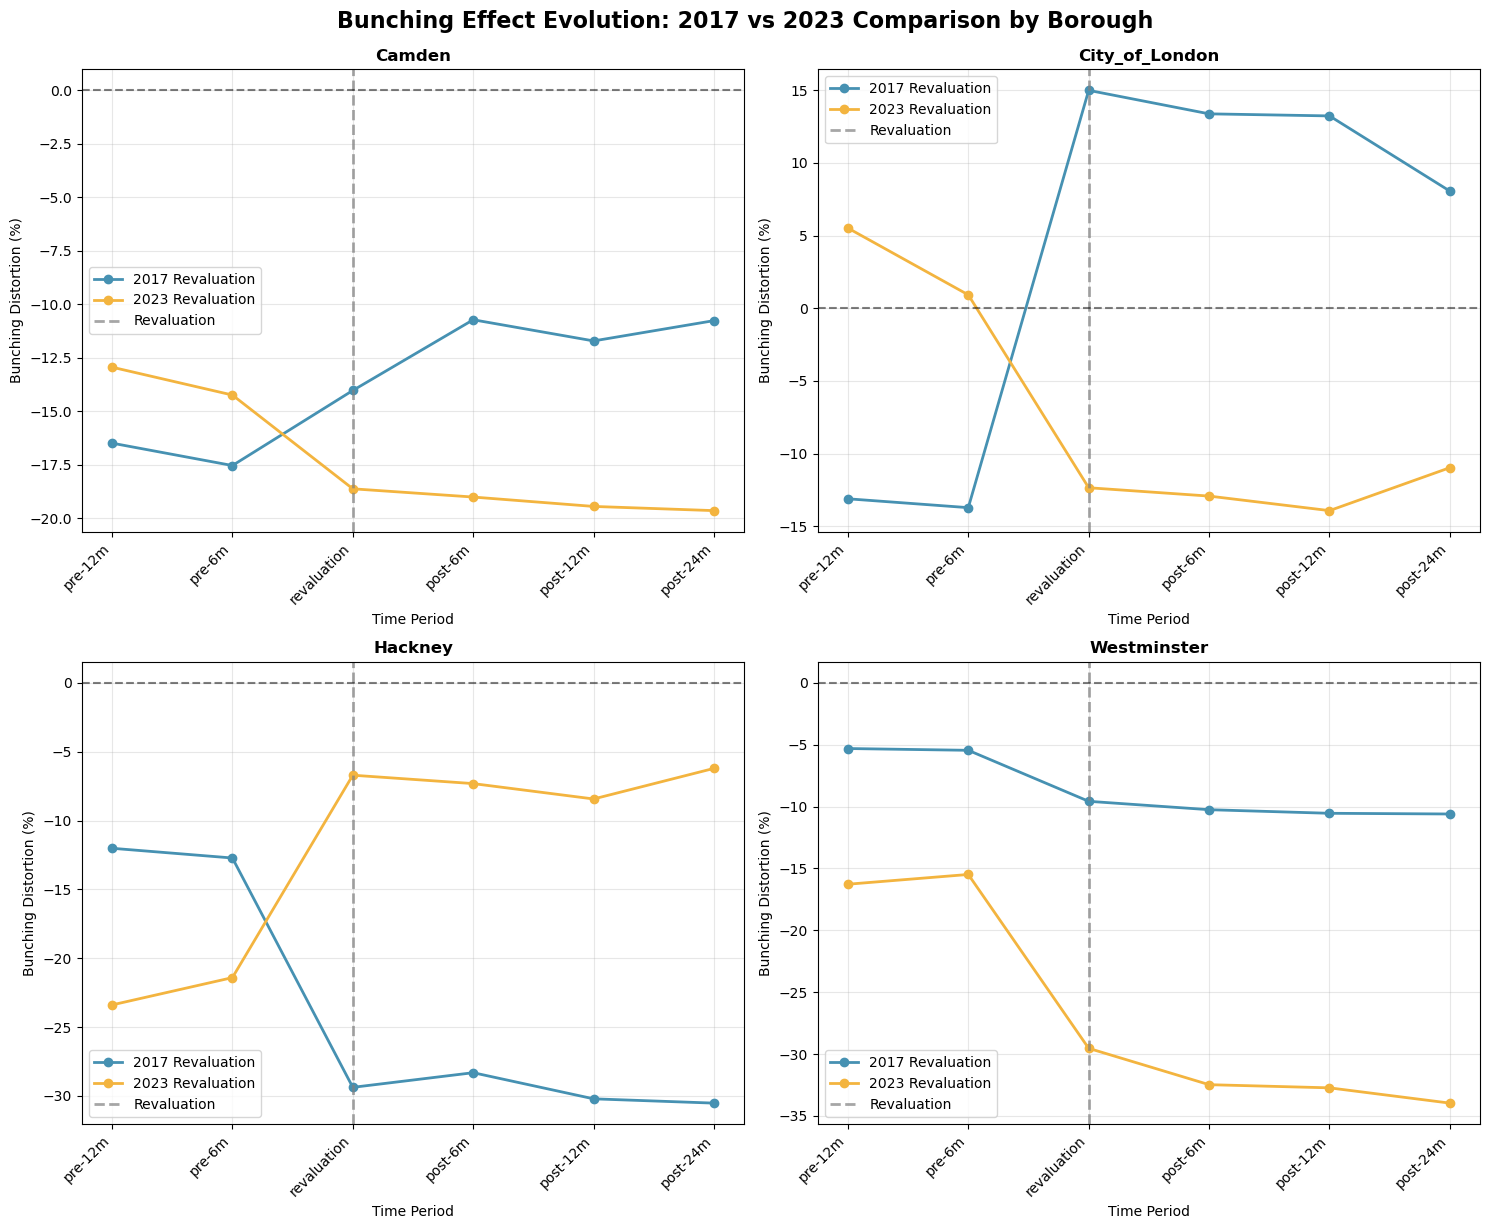

In [22]:
def plot_bunching_evolution_by_borough(all_borough_both_periods):
    """Plot bunching evolution for each borough with 2017 vs 2023 comparison"""
    
    # Extract bunching data
    bunching_data = []
    for borough_name, periods_data in all_borough_both_periods.items():
        for period, results in periods_data.items():
            if results is not None and len(results['bunching']) > 0:
                year = period.split('_')[0]
                for _, row in results['bunching'].iterrows():
                    bunching_data.append({
                        'Borough': borough_name,
                        'Year': year,
                        'Period': row['period'],
                        'Distortion': row['distortion_pct']
                    })

    bunching_df = pd.DataFrame(bunching_data)
    
    # Set up the subplot layout
    boroughs = bunching_df['Borough'].unique()
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    # Define colors for different years
    colors = {
        '2017': '#4691B2',  
        '2023': '#F3B43F' 
    }
    
    # Period order for x-axis
    period_order = ['pre_12m', 'pre_6m', 'revaluation', 'post_6m', 'post_12m', 'post_24m']
    period_labels = ['Pre-12m', 'Pre-6m', 'Revaluation', 'Post-6m', 'Post-12m', 'Post-24m']
    
    for i, borough in enumerate(boroughs):
        ax = axes[i]
        borough_data = bunching_df[bunching_df['Borough'] == borough]
        
        # Plot 2017 and 2023 lines
        for year in ['2017', '2023']:
            year_data = borough_data[borough_data['Year'] == year]
            if len(year_data) > 0:
                # Reorder data according to period_order
                ordered_data = []
                ordered_labels = []
                for period in period_order:
                    period_row = year_data[year_data['Period'] == period]
                    if len(period_row) > 0:
                        ordered_data.append(period_row['Distortion'].iloc[0])
                        ordered_labels.append(period)
                
                # Plot line
                ax.plot(range(len(ordered_data)), ordered_data, 
                        marker='o', linewidth=2, markersize=6, 
                        color=colors[year], 
                        label=f'{year} Revaluation')
                # Add vertical line at revaluation point
        revaluation_index = None
        if len(ordered_labels) > 0:
            try:
                revaluation_index = ordered_labels.index('revaluation')
                ax.axvline(x=revaluation_index, color='grey', linestyle='--', 
                          alpha=0.7, linewidth=2, label='Revaluation')
            except ValueError:
                pass  # revaluation not in this borough's data
                
        
        # Formatting
        ax.set_title(f'{borough}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time Period', fontsize=10)
        ax.set_ylabel('Bunching Distortion (%)', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Set x-axis labels
        if len(ordered_labels) > 0:
            ax.set_xticks(range(len(ordered_labels)))
            ax.set_xticklabels([label.replace('_', '-') for label in ordered_labels], 
                              rotation=45, ha='right')
    
    plt.tight_layout()
    plt.suptitle('Bunching Effect Evolution: 2017 vs 2023 Comparison by Borough', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    return fig

# Execute the visualization
fig = plot_bunching_evolution_by_borough(all_borough_both_periods)

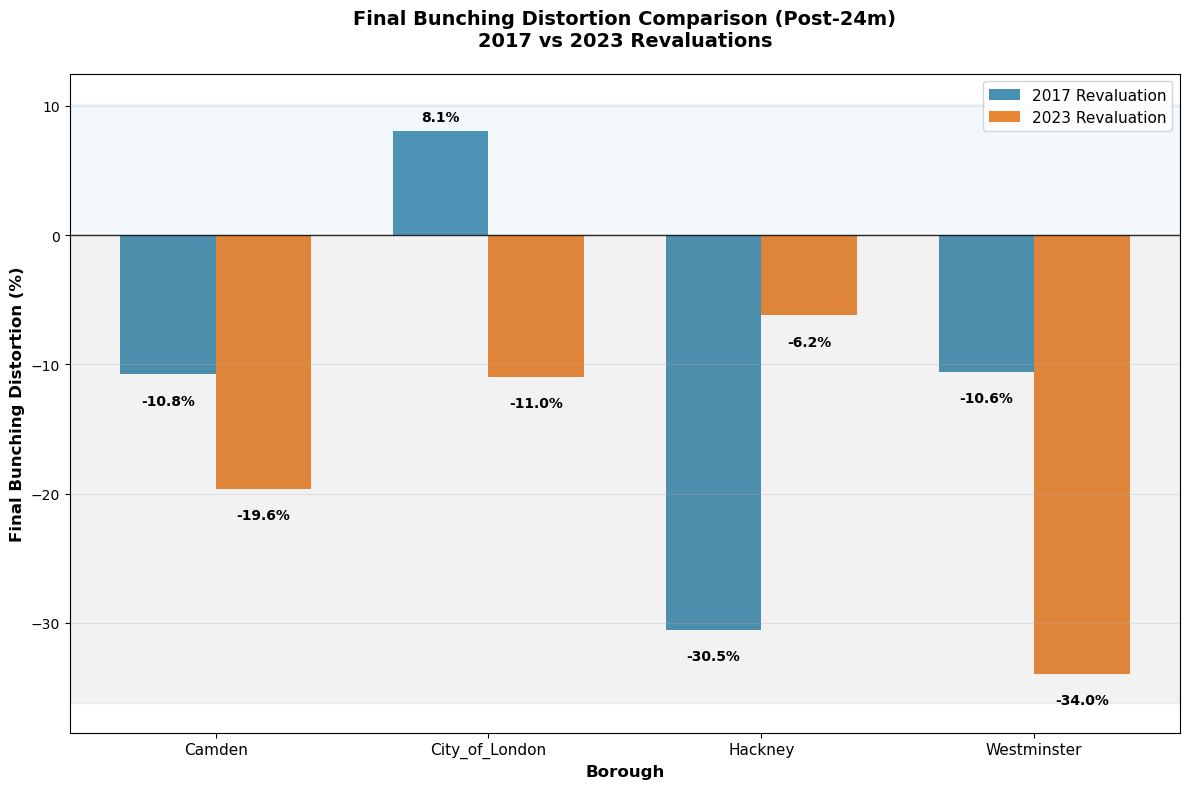


Final Bunching Distortion Summary:
Borough          | 2017  | 2023  | Change
----------------------------------------
Camden          | -10.8 | -19.6 |   -8.9
City_of_London  |   8.1 | -11.0 |  -19.0
Hackney         | -30.5 |  -6.2 |  +24.3
Westminster     | -10.6 | -34.0 |  -23.4


In [36]:
def plot_final_bunching_comparison(all_borough_both_periods):
    """Plot final bunching distortion comparison across boroughs (2017 vs 2023)"""
    
    # Extract final bunching distortion data (post_24m)
    final_data = []
    
    for borough_name, periods_data in all_borough_both_periods.items():
        borough_final = {'Borough': borough_name}
        
        for period, results in periods_data.items():
            if results is not None and len(results['bunching']) > 0:
                year = period.split('_')[0]
                # Get post_24m data
                final_bunching = results['bunching'][results['bunching']['period'] == 'post_24m']
                if len(final_bunching) > 0:
                    borough_final[year] = final_bunching['distortion_pct'].iloc[0]
        
        final_data.append(borough_final)
    
    # Create DataFrame
    final_df = pd.DataFrame(final_data)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    
    boroughs = final_df['Borough']
    x = np.arange(len(boroughs))
    width = 0.35
    
    # Create bars
    bars_2017 = ax.bar(x - width/2, final_df['2017'], width, 
                       label='2017 Revaluation', color='#4790B2')
    bars_2023 = ax.bar(x + width/2, final_df['2023'], width, 
                       label='2023 Revaluation', color='#EA8632')
    
    # Add value labels on top of bars
    def add_value_labels(bars, values):
        for bar, value in zip(bars, values):
            if pd.notna(value):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + (0.5 if height >= 0 else -1.5),
                       f'{value:.1f}%', ha='center', va='bottom' if height >= 0 else 'top',
                       fontweight='bold', fontsize=10)
    
    add_value_labels(bars_2017, final_df['2017'])
    add_value_labels(bars_2023, final_df['2023'])
    
    # Formatting
    ax.set_xlabel('Borough', fontsize=12, fontweight='bold')
    ax.set_ylabel('Final Bunching Distortion (%)', fontsize=12, fontweight='bold')
    ax.set_title('Final Bunching Distortion Comparison (Post-24m)\n2017 vs 2023 Revaluations', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(boroughs, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    
    # Add background colors for positive/negative regions
    ax.axhspan(0, ax.get_ylim()[1], alpha=0.1, color='#8EBEE2', label='Less Distortion')
    ax.axhspan(ax.get_ylim()[0], 0, alpha=0.1, color='grey', label='More Distortion')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\nFinal Bunching Distortion Summary:")
    print("Borough          | 2017  | 2023  | Change")
    print("-" * 40)
    for _, row in final_df.iterrows():
        change = row['2023'] - row['2017'] if pd.notna(row['2017']) and pd.notna(row['2023']) else np.nan
        print(f"{row['Borough']:<15} | {row['2017']:>5.1f} | {row['2023']:>5.1f} | {change:>+6.1f}")
    
    return fig, final_df

# Execute the visualization
fig, final_comparison_data = plot_final_bunching_comparison(all_borough_both_periods)

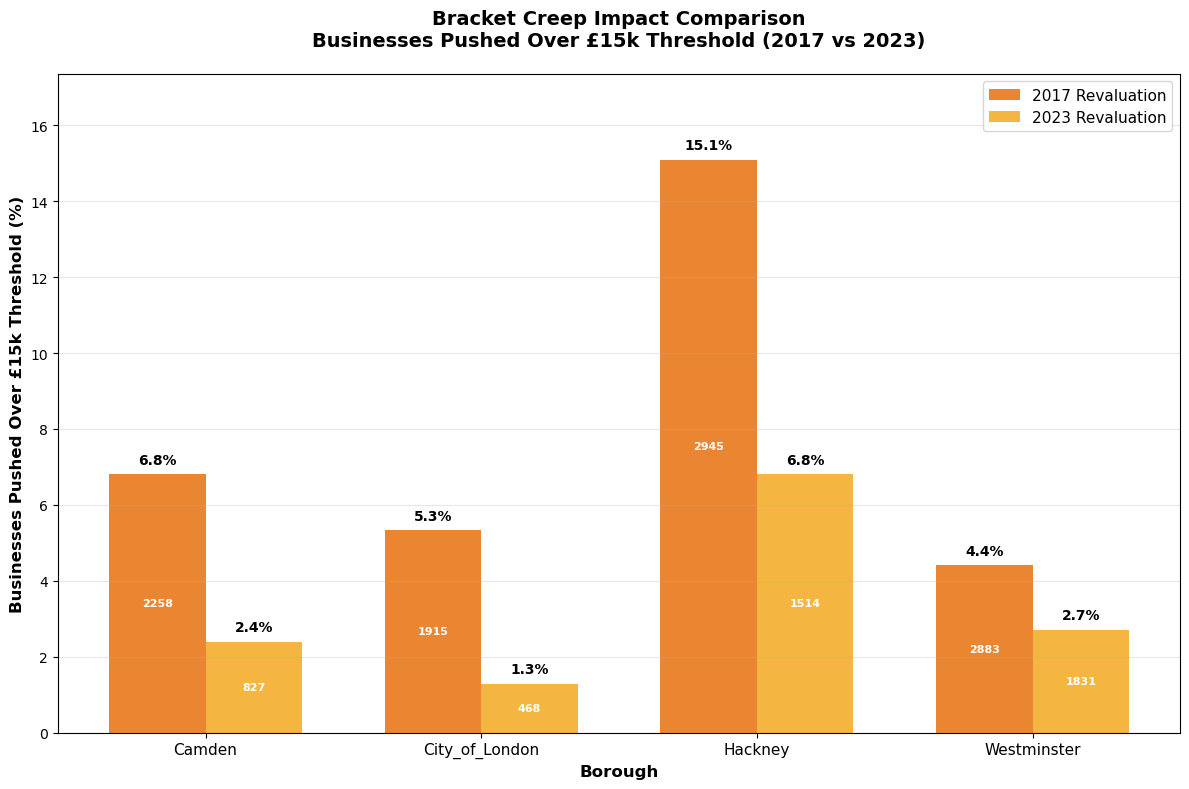


Bracket Creep Impact Summary:
Borough          | 2017      | 2023      | Change
                 | Rate | #  | Rate | #  | Rate
-------------------------------------------------------
Camden          |  6.8%|2258 |  2.4%|827 |  -4.4%
City_of_London  |  5.3%|1915 |  1.3%|468 |  -4.0%
Hackney         | 15.1%|2945 |  6.8%|1514 |  -8.3%
Westminster     |  4.4%|2883 |  2.7%|1831 |  -1.7%


In [42]:
def plot_bracket_creep_impact_comparison(all_borough_both_periods):
    """Plot bracket creep impact comparison across boroughs (2017 vs 2023)"""
    
    # Extract bracket creep impact data
    bracket_data = []
    
    for borough_name, periods_data in all_borough_both_periods.items():
        borough_impact = {'Borough': borough_name}
        
        for period, results in periods_data.items():
            if results is not None and len(results['responses']) > 0:
                year = period.split('_')[0]
                # Calculate bracket creep impact percentage
                affected = results['responses']['affected_15k_threshold'].sum()
                total = len(results['responses'])
                impact_pct = (affected / total * 100) if total > 0 else 0
                borough_impact[year] = impact_pct
                borough_impact[f'{year}_count'] = affected
                borough_impact[f'{year}_total'] = total
        
        bracket_data.append(borough_impact)
    
    # Create DataFrame
    bracket_df = pd.DataFrame(bracket_data)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    
    boroughs = bracket_df['Borough']
    x = np.arange(len(boroughs))
    width = 0.35
    
    # Create bars
    bars_2017 = ax.bar(x - width/2, bracket_df['2017'], width, 
                       label='2017 Revaluation', color='#EA8632')
    bars_2023 = ax.bar(x + width/2, bracket_df['2023'], width, 
                       label='2023 Revaluation', color='#F4B641')
    
    # Add value labels on top of bars
    def add_bracket_labels(bars, percentages, counts, totals):
        for bar, pct, count, total in zip(bars, percentages, counts, totals):
            if pd.notna(pct) and pd.notna(count) and pd.notna(total):
                height = bar.get_height()
                # Main percentage label
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                       f'{pct:.1f}%', ha='center', va='bottom',
                       fontweight='bold', fontsize=10)
                # Count label inside bar
                if height > 1:  # Only show if bar is tall enough
                    ax.text(bar.get_x() + bar.get_width()/2., height/2,
                           f'{int(count)}', ha='center', va='center',
                           fontsize=8, color='white', fontweight='bold')
    
    add_bracket_labels(bars_2017, bracket_df['2017'], 
                      bracket_df['2017_count'], bracket_df['2017_total'])
    add_bracket_labels(bars_2023, bracket_df['2023'], 
                      bracket_df['2023_count'], bracket_df['2023_total'])
    
    # Formatting
    ax.set_xlabel('Borough', fontsize=12, fontweight='bold')
    ax.set_ylabel('Businesses Pushed Over £15k Threshold (%)', fontsize=12, fontweight='bold')
    ax.set_title('Bracket Creep Impact Comparison\nBusinesses Pushed Over £15k Threshold (2017 vs 2023)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(boroughs, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis to start from 0
    ax.set_ylim(0, max(bracket_df['2017'].max(), bracket_df['2023'].max()) * 1.15)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary table
    print("\nBracket Creep Impact Summary:")
    print("Borough          | 2017      | 2023      | Change")
    print("                 | Rate | #  | Rate | #  | Rate")
    print("-" * 55)
    for _, row in bracket_df.iterrows():
        rate_2017 = row['2017'] if pd.notna(row['2017']) else 0
        rate_2023 = row['2023'] if pd.notna(row['2023']) else 0
        count_2017 = int(row['2017_count']) if pd.notna(row['2017_count']) else 0
        count_2023 = int(row['2023_count']) if pd.notna(row['2023_count']) else 0
        change = rate_2023 - rate_2017
        
        print(f"{row['Borough']:<15} | {rate_2017:>4.1f}%|{count_2017:>3} | {rate_2023:>4.1f}%|{count_2023:>3} | {change:>+5.1f}%")
    
    return fig, bracket_df

# Execute the visualization
fig_bracket, bracket_impact_data = plot_bracket_creep_impact_comparison(all_borough_both_periods)

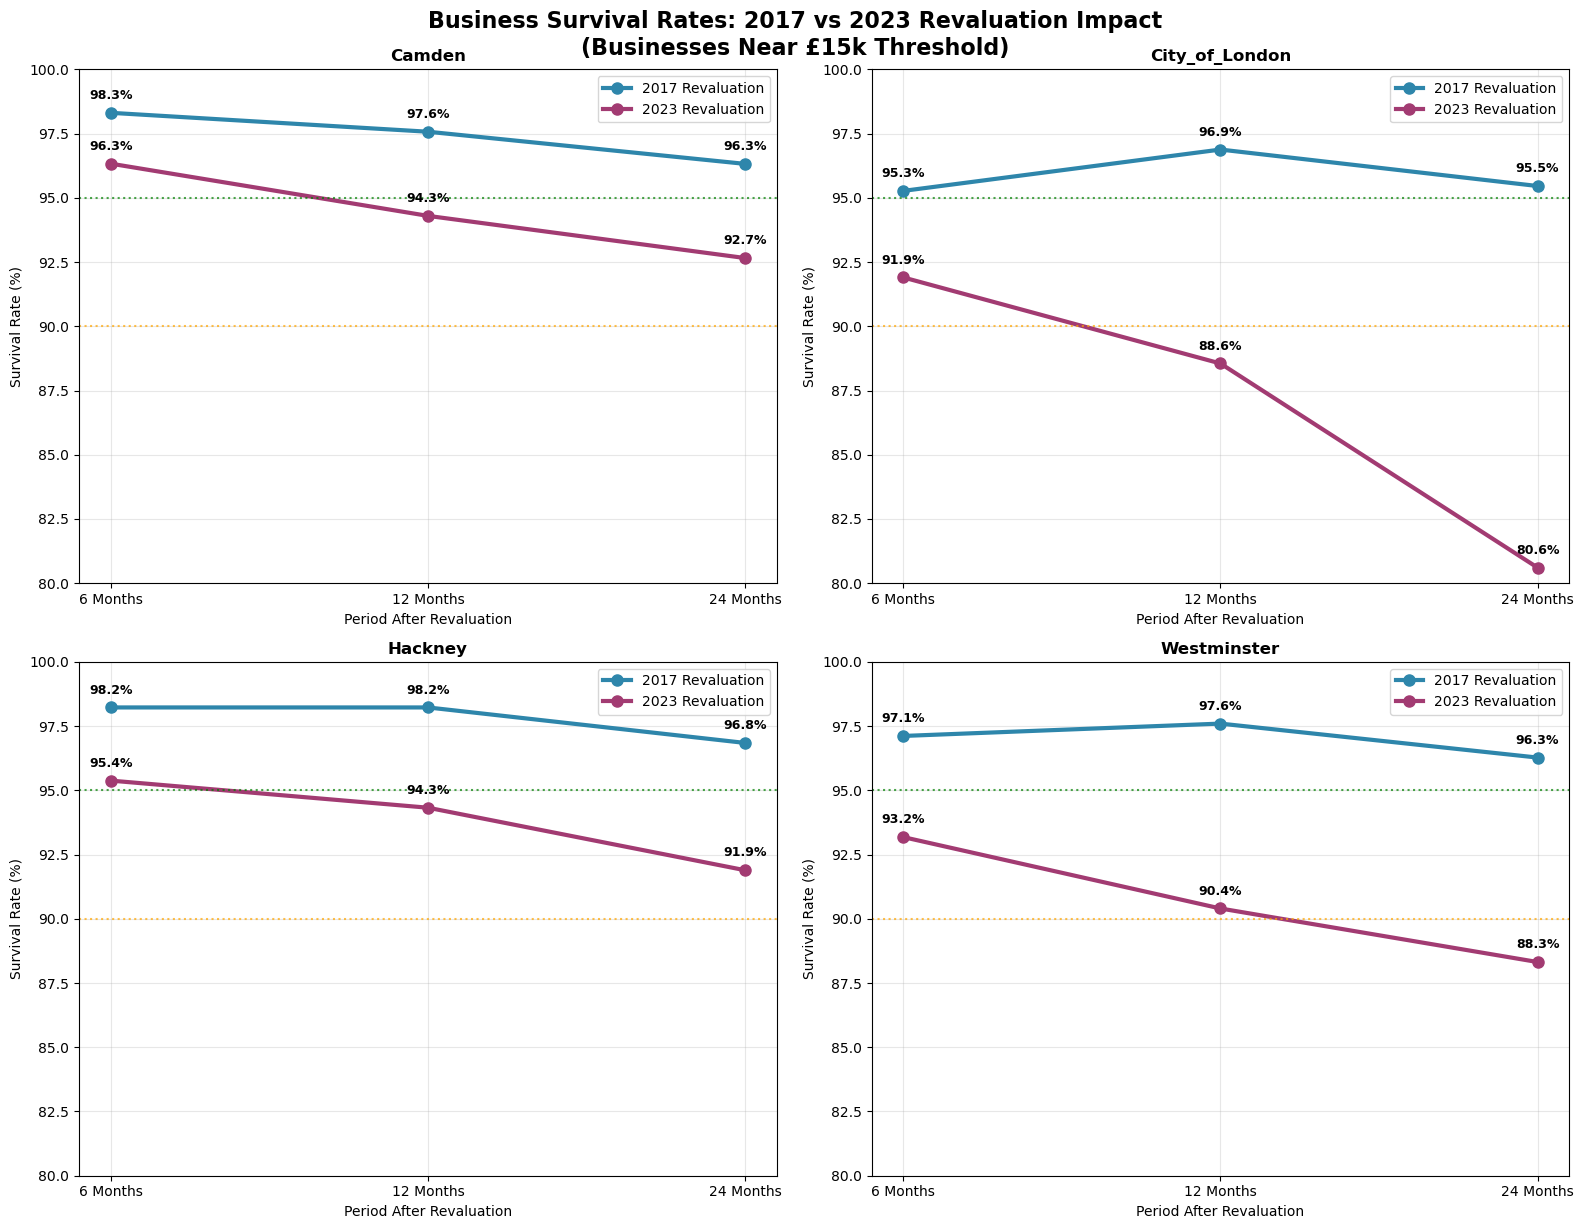


Business Survival Rate Summary (Near £15k Threshold):

CAMDEN:
Period    | 2017  | 2023  | Change
-----------------------------------
6 months |  98.3 |  96.3 |   -2.0
12 months |  97.6 |  94.3 |   -3.3
24 months |  96.3 |  92.7 |   -3.7

CITY_OF_LONDON:
Period    | 2017  | 2023  | Change
-----------------------------------
6 months |  95.3 |  91.9 |   -3.4
12 months |  96.9 |  88.6 |   -8.3
24 months |  95.5 |  80.6 |  -14.9

HACKNEY:
Period    | 2017  | 2023  | Change
-----------------------------------
6 months |  98.2 |  95.4 |   -2.8
12 months |  98.2 |  94.3 |   -3.9
24 months |  96.8 |  91.9 |   -5.0

WESTMINSTER:
Period    | 2017  | 2023  | Change
-----------------------------------
6 months |  97.1 |  93.2 |   -3.9
12 months |  97.6 |  90.4 |   -7.2
24 months |  96.3 |  88.3 |   -8.0


In [45]:
def plot_business_survival_comparison(all_borough_both_periods):
    """Plot business survival rates comparison across periods (2017 vs 2023)"""
    
    # Extract survival data
    survival_data = []
    
    for borough_name, periods_data in all_borough_both_periods.items():
        for period, results in periods_data.items():
            if results is not None and len(results['survival']) > 0:
                year = period.split('_')[0]
                survival_df = results['survival'].copy()
                survival_df['Borough'] = borough_name
                survival_df['Revaluation_Year'] = year
                survival_data.append(survival_df)
    
    # Combine all survival data
    combined_survival = pd.concat(survival_data, ignore_index=True)
    
    # Filter for post periods only
    post_periods = ['post_6m', 'post_12m', 'post_24m']
    survival_filtered = combined_survival[combined_survival['period'].isin(post_periods)]
    
    # Set up the subplot layout
    boroughs = survival_filtered['Borough'].unique()
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Define colors for different years
    colors = {
        '2017': '#2E86AB',  # Blue
        '2023': '#A23B72'   # Pink
    }
    
    # Period order and labels
    period_order = ['post_6m', 'post_12m', 'post_24m']
    period_labels = ['6 Months', '12 Months', '24 Months']
    
    for i, borough in enumerate(boroughs):
        ax = axes[i]
        borough_data = survival_filtered[survival_filtered['Borough'] == borough]
        
        # Plot lines for 2017 and 2023
        for year in ['2017', '2023']:
            year_data = borough_data[borough_data['Revaluation_Year'] == year]
            if len(year_data) > 0:
                # Reorder data according to period_order
                ordered_survival = []
                for period in period_order:
                    period_data = year_data[year_data['period'] == period]
                    if len(period_data) > 0:
                        survival_rate = period_data['survival_rate_near_threshold'].iloc[0]
                        ordered_survival.append(survival_rate)
                    else:
                        ordered_survival.append(np.nan)
                
                # Plot line
                ax.plot(range(len(period_order)), ordered_survival, 
                       marker='o', linewidth=3, markersize=8, 
                       color=colors[year], label=f'{year} Revaluation')
                
                # Add value labels
                for j, value in enumerate(ordered_survival):
                    if not pd.isna(value):
                        ax.annotate(f'{value:.1f}%', 
                                  (j, value), 
                                  textcoords="offset points", 
                                  xytext=(0,10), 
                                  ha='center', fontweight='bold', fontsize=9)
        
        # Formatting
        ax.set_title(f'{borough}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Period After Revaluation', fontsize=10)
        ax.set_ylabel('Survival Rate (%)', fontsize=10)
        ax.set_xticks(range(len(period_order)))
        ax.set_xticklabels(period_labels)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        
        # Set y-axis range for better comparison
        ax.set_ylim(80, 100)  # Focus on the range where data varies
        
        # Add horizontal reference lines
        ax.axhline(y=90, color='orange', linestyle=':', alpha=0.7, label='90% Reference')
        ax.axhline(y=95, color='green', linestyle=':', alpha=0.7, label='95% Reference')
    
    plt.tight_layout()
    plt.suptitle('Business Survival Rates: 2017 vs 2023 Revaluation Impact\n(Businesses Near £15k Threshold)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # Print summary statistics
    print("\nBusiness Survival Rate Summary (Near £15k Threshold):")
    print("="*70)
    
    for borough in boroughs:
        print(f"\n{borough.upper()}:")
        borough_data = survival_filtered[survival_filtered['Borough'] == borough]
        
        print("Period    | 2017  | 2023  | Change")
        print("-" * 35)
        
        for period in period_order:
            data_2017 = borough_data[(borough_data['period'] == period) & 
                                   (borough_data['Revaluation_Year'] == '2017')]
            data_2023 = borough_data[(borough_data['period'] == period) & 
                                   (borough_data['Revaluation_Year'] == '2023')]
            
            rate_2017 = data_2017['survival_rate_near_threshold'].iloc[0] if len(data_2017) > 0 else np.nan
            rate_2023 = data_2023['survival_rate_near_threshold'].iloc[0] if len(data_2023) > 0 else np.nan
            change = rate_2023 - rate_2017 if pd.notna(rate_2017) and pd.notna(rate_2023) else np.nan
            
            period_label = period.replace('post_', '').replace('m', ' months')
            print(f"{period_label:<8} | {rate_2017:>5.1f} | {rate_2023:>5.1f} | {change:>+6.1f}")
    
    return fig

# Execute the visualization
fig_survival = plot_business_survival_comparison(all_borough_both_periods)

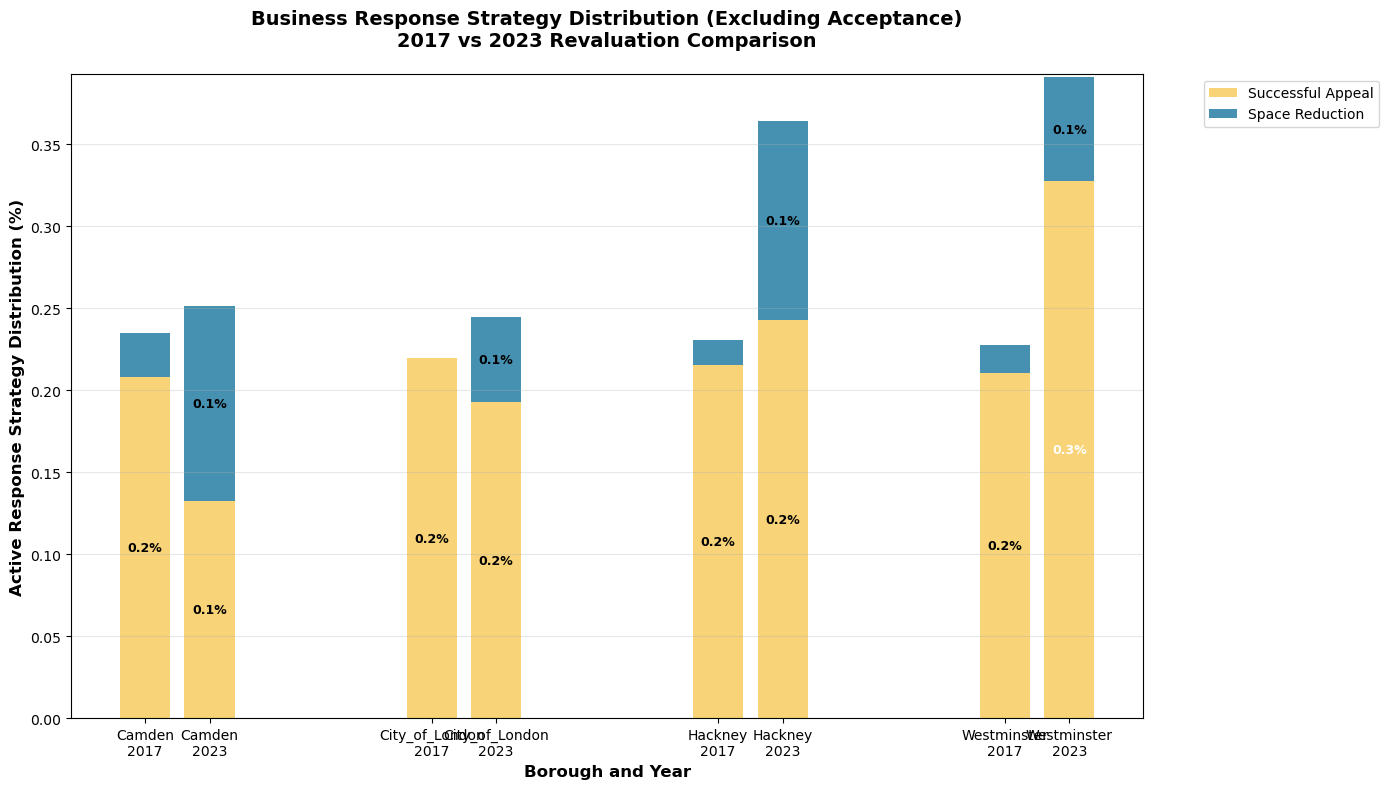


Active Response Strategy Distribution Summary (Excluding Acceptance):

CAMDEN:
Strategy           | 2017      | 2023      | Change
                   | %    | #  | %    | #  | %
-------------------------------------------------------
Successful Appeal  |  0.2%| 69 |  0.1%| 46 |  -0.1%
Space Reduction    |  0.0%|  9 |  0.1%| 41 |  +0.1%

CITY_OF_LONDON:
Strategy           | 2017      | 2023      | Change
                   | %    | #  | %    | #  | %
-------------------------------------------------------
Successful Appeal  |  0.2%| 79 |  0.2%| 70 |  -0.0%
Space Reduction    |  0.0%|  0 |  0.1%| 19 |  +0.1%

HACKNEY:
Strategy           | 2017      | 2023      | Change
                   | %    | #  | %    | #  | %
-------------------------------------------------------
Successful Appeal  |  0.2%| 42 |  0.2%| 54 |  +0.0%
Space Reduction    |  0.0%|  3 |  0.1%| 27 |  +0.1%

WESTMINSTER:
Strategy           | 2017      | 2023      | Change
                   | %    | #  | %    | #  | %
---

In [50]:
def plot_response_strategy_distribution(all_borough_both_periods):
    """Plot response strategy distribution comparison (2017 vs 2023) - excluding acceptance"""
    
    # Extract response strategy data
    strategy_data = []
    
    for borough_name, periods_data in all_borough_both_periods.items():
        for period, results in periods_data.items():
            if results is not None and len(results['responses']) > 0:
                year = period.split('_')[0]
                responses = results['responses']
                
                # Count strategies (excluding acceptance)
                strategy_counts = responses[responses['strategy'] != 'acceptance'].groupby('strategy').size()
                total_businesses = len(responses)  # Keep total including acceptance for percentage calculation
                
                # Calculate percentages
                for strategy, count in strategy_counts.items():
                    percentage = (count / total_businesses) * 100
                    strategy_data.append({
                        'Borough': borough_name,
                        'Year': year,
                        'Strategy': strategy,
                        'Count': count,
                        'Percentage': percentage,
                        'Total_Businesses': total_businesses
                    })
    
    # Create DataFrame
    strategy_df = pd.DataFrame(strategy_data)
    
    # Define strategy order and colors
    strategy_order = ['successful_appeal', 'space_reduction']
    strategy_colors = {
        'successful_appeal': '#F8D378', 
        'space_reduction': '#4691B2'         
    }
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create borough-year combinations
    boroughs = sorted(strategy_df['Borough'].unique())
    years = ['2017', '2023']
    
    # Calculate positions for bars
    x_positions = []
    x_labels = []
    bar_width = 0.35
    
    for i, borough in enumerate(boroughs):
        # Add positions for 2017 and 2023
        base_pos = i * 2
        x_positions.extend([base_pos, base_pos + bar_width + 0.1])
        x_labels.extend([f'{borough}\n2017', f'{borough}\n2023'])
    
    # Prepare data for stacked bars
    strategy_data_plot = {}
    for strategy in strategy_order:
        strategy_data_plot[strategy] = []
        
        for borough in boroughs:
            for year in years:
                data_point = strategy_df[
                    (strategy_df['Borough'] == borough) & 
                    (strategy_df['Year'] == year) & 
                    (strategy_df['Strategy'] == strategy)
                ]
                
                if len(data_point) > 0:
                    strategy_data_plot[strategy].append(data_point['Percentage'].iloc[0])
                else:
                    strategy_data_plot[strategy].append(0)
    
    # Create stacked bars
    bottom_values = [0] * len(x_positions)
    
    for strategy in strategy_order:
        bars = ax.bar(x_positions, strategy_data_plot[strategy], 
                     bar_width, bottom=bottom_values,
                     color=strategy_colors[strategy], 
                     label=strategy.replace('_', ' ').title())
        
        # Add percentage labels for all values (since they're now more visible)
        for i, (bar, value) in enumerate(zip(bars, strategy_data_plot[strategy])):
            if value > 0.05:  # Show labels for values > 0.05%
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., 
                       bottom_values[i] + height/2,
                       f'{value:.1f}%', 
                       ha='center', va='center', 
                       fontweight='bold', fontsize=9,
                       color='white' if value > 0.3 else 'black')
        
        # Update bottom values for next stack
        bottom_values = [bottom + value for bottom, value in zip(bottom_values, strategy_data_plot[strategy])]
    
    # Formatting
    ax.set_xlabel('Borough and Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Active Response Strategy Distribution (%)', fontsize=12, fontweight='bold')
    ax.set_title('Business Response Strategy Distribution (Excluding Acceptance)\n2017 vs 2023 Revaluation Comparison', 
                 fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust y-axis range since we're not showing acceptance (which dominates)
    max_value = max([max(strategy_data_plot[strategy]) for strategy in strategy_order])
    ax.set_ylim(0, max_value * 1.2)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary table (excluding acceptance)
    print("\nActive Response Strategy Distribution Summary (Excluding Acceptance):")
    print("="*80)
    
    for borough in boroughs:
        print(f"\n{borough.upper()}:")
        print("Strategy           | 2017      | 2023      | Change")
        print("                   | %    | #  | %    | #  | %")
        print("-" * 55)
        
        borough_data = strategy_df[strategy_df['Borough'] == borough]
        
        for strategy in strategy_order:
            data_2017 = borough_data[
                (borough_data['Year'] == '2017') & 
                (borough_data['Strategy'] == strategy)
            ]
            data_2023 = borough_data[
                (borough_data['Year'] == '2023') & 
                (borough_data['Strategy'] == strategy)
            ]
            
            pct_2017 = data_2017['Percentage'].iloc[0] if len(data_2017) > 0 else 0
            pct_2023 = data_2023['Percentage'].iloc[0] if len(data_2023) > 0 else 0
            count_2017 = int(data_2017['Count'].iloc[0]) if len(data_2017) > 0 else 0
            count_2023 = int(data_2023['Count'].iloc[0]) if len(data_2023) > 0 else 0
            change = pct_2023 - pct_2017
            
            strategy_name = strategy.replace('_', ' ').title()
            print(f"{strategy_name:<18} | {pct_2017:>4.1f}%|{count_2017:>3} | {pct_2023:>4.1f}%|{count_2023:>3} | {change:>+5.1f}%")
    
    return fig, strategy_df

# Execute the visualization
fig_strategy, strategy_distribution_data = plot_response_strategy_distribution(all_borough_both_periods)

In [54]:
# Export summary analysis to Excel with multiple sheets
def export_summary_analysis(all_borough_both_periods, filename='bracket_creep_analysis.xlsx'):
    import pandas as pd
    
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        
        # 1. Bunching Effect Summary
        bunching_summary = []
        for borough, periods in all_borough_both_periods.items():
            for period, results in periods.items():
                if results is not None and len(results['bunching']) > 0:
                    for _, row in results['bunching'].iterrows():
                        bunching_summary.append({
                            'Borough': borough,
                            'Revaluation_Year': period.split('_')[0],
                            'Period': row['period'],
                            'Threshold': row['threshold'],
                            'Distortion_Pct': row['distortion_pct'],
                            'Before_Count': row['before_count'],
                            'After_Count': row['after_count']
                        })
        
        bunching_df = pd.DataFrame(bunching_summary)
        bunching_df.to_excel(writer, sheet_name='Bunching_Analysis', index=False)
        
        # 2. Survival Rates Summary
        survival_summary = []
        for borough, periods in all_borough_both_periods.items():
            for period, results in periods.items():
                if results is not None and len(results['survival']) > 0:
                    for _, row in results['survival'].iterrows():
                        survival_summary.append({
                            'Borough': borough,
                            'Revaluation_Year': period.split('_')[0],
                            'Period': row['period'],
                            'Threshold': row['threshold'],
                            'Total_Baseline': row['total_baseline'],
                            'Near_Threshold_Baseline': row['near_threshold_baseline'],
                            'Survival_Rate_Total': row['survival_rate_total'],
                            'Survival_Rate_Near_Threshold': row['survival_rate_near_threshold']
                        })
        
        survival_df = pd.DataFrame(survival_summary)
        survival_df.to_excel(writer, sheet_name='Survival_Analysis', index=False)
        
        # 3. Response Strategy Summary
        strategy_summary = []
        for borough, periods in all_borough_both_periods.items():
            for period, results in periods.items():
                if results is not None and len(results['responses']) > 0:
                    strategy_counts = results['responses'].groupby(['strategy', 'affected_15k_threshold']).size().unstack(fill_value=0)
                    for strategy in strategy_counts.index:
                        strategy_summary.append({
                            'Borough': borough,
                            'Revaluation_Year': period.split('_')[0],
                            'Strategy': strategy,
                            'Not_Affected': strategy_counts.loc[strategy, False] if False in strategy_counts.columns else 0,
                            'Affected_15k': strategy_counts.loc[strategy, True] if True in strategy_counts.columns else 0,
                            'Total': strategy_counts.loc[strategy].sum()
                        })
        
        strategy_df = pd.DataFrame(strategy_summary)
        strategy_df.to_excel(writer, sheet_name='Response_Strategies', index=False)
        
        # 4. Key Metrics Comparison
        comparison_data = []
        for borough, periods in all_borough_both_periods.items():
            row = {'Borough': borough}
            
            for period, results in periods.items():
                year = period.split('_')[0]
                
                if results is not None:
                    # Final bunching distortion
                    bunching_data = results['bunching']
                    if len(bunching_data) > 0:
                        final_bunching = bunching_data[bunching_data['period'] == 'post_24m']
                        if len(final_bunching) > 0:
                            row[f'{year}_Final_Distortion_Pct'] = final_bunching['distortion_pct'].iloc[0]
                    
                    # Final survival rate
                    survival_data = results['survival']
                    if len(survival_data) > 0:
                        final_survival = survival_data[survival_data['period'] == 'post_24m']
                        if len(final_survival) > 0:
                            row[f'{year}_Final_Survival_Rate'] = final_survival['survival_rate_near_threshold'].iloc[0]
                    
                    # Bracket creep impact
                    responses = results['responses']
                    if len(responses) > 0:
                        affected = responses['affected_15k_threshold'].sum()
                        total = len(responses)
                        row[f'{year}_Bracket_Creep_Impact_Pct'] = (affected/total*100) if total > 0 else 0
                        row[f'{year}_Total_Businesses'] = total
            
            comparison_data.append(row)
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df.to_excel(writer, sheet_name='Key_Metrics_Comparison', index=False)
    
    print(f"✓ Summary analysis exported to {filename}")

# Execute summary export
export_summary_analysis(all_borough_both_periods)

✓ Summary analysis exported to bracket_creep_analysis.xlsx


## Forecast
- 训练集（17年）→测试集（23年）→预测集（26年）
- 17年和23年的6个时间节点来预测生存、价值变化、bracket creep影响
- 

2. 机器学习预测模型

特征：企业rateable_value、地理位置、历史变化模式 \
标签：基于17年和23年的企业应对行为
模型：预测每个企业在2026重估后的状态 

3. 情景分析

轻度重估：基于17年模式
重度重估：基于23年模式

### 预测分析思路
第一步：历史趋势识别

Bunching效应演变模式：对比2017和2023两次重估的bunching强度变化趋势
企业适应速度：分析企业在两次重估中的反应时间差异（是否越来越快适应）
策略学习效应：企业是否在2023年采用了更有效的应对策略

第二步：建立预测模型基础

时间序列分析：基于6个时间点的bunching distortion数据建立趋势模型
生存率预测模型：根据历史生存率模式预测企业退出概率
策略演变模型：预测企业应对策略的采用比例变化

第三步：关键假设设定

政策连续性：假设£15,000门槛保持不变
经济环境：考虑通胀、市场条件等宏观因素
企业学习曲线：假设企业在第三次重估中应对能力进一步提升

第四步：预测维度

Bunching强度预测：2025年门槛附近的分布扭曲程度
企业退出率预测：ultra-high risk和high risk退出比例
策略分布预测：successful appeal、space reduction等策略采用率
地区差异预测：四个borough的不同影响程度

第五步：情景分析

乐观情景：企业完全适应，bunching效应显著减弱
悲观情景：累积效应，bracket creep影响加剧
现实情景：基于历史趋势的中性预测

第六步：模型验证

交叉验证：用2017数据预测2023，检验模型准确性
敏感性分析：测试关键参数变化对预测结果的影响

这种方法能够提供2025年重估影响的量化预测和政策建议。

In [56]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score